In [1]:
from MLtools import ImageData, SC_Model
from torch.utils.data import DataLoader, random_split
import torch
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from torchvision.transforms import Resize

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

model = torch.load("SC_model2.pth", weights_only=False).to(device)

In [59]:
name = "datasets/camera/4.jpg"
transform = Resize((640,640))

image = imageio.imread(name)
image = image.swapaxes(0,2).swapaxes(1,2)/255.0
image = torch.from_numpy(image)
image = transform(image)
image = torch.unsqueeze(image, 0)

print(image.shape)

torch.Size([1, 3, 640, 640])


In [60]:
with torch.no_grad():
    heat_map = model(image.float().to(device)).view((640,640))

heat_map.shape

torch.Size([640, 640])

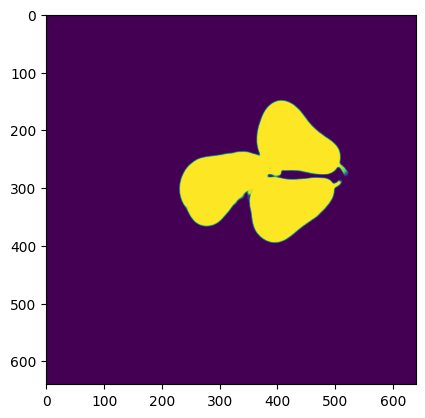

In [61]:
heat_map = heat_map.to('cpu').numpy()
plt.imshow(heat_map)

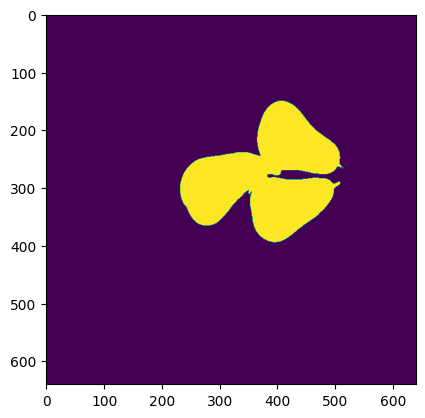

In [62]:
ind = np.where(heat_map > 0.9)
pic = np.zeros((640,640))
pic[ind] = 1
plt.imshow(pic)

In [7]:
print(f'N pixels: {len(ind[0])}')

N pixels: 53207


In [8]:
len(ind[0])/640**2

0.12989990234375

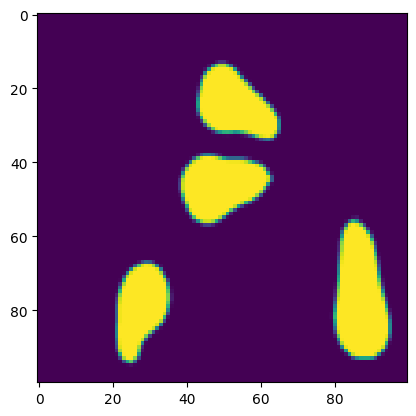

In [9]:
tr = Resize((100, 100))

pic = torch.from_numpy(pic)
pic = torch.unsqueeze(pic, 0)
pic = tr(pic).view((100,100)).numpy()

ind = np.where(pic > 0.9)

plt.imshow(pic)

In [10]:
X = []
for i in range(len(ind[0])):
    X.append([ind[0][i], ind[1][i]])

In [11]:
from sklearn.cluster import MeanShift

clustering = MeanShift(bandwidth=20).fit(X)

In [12]:
len(clustering.cluster_centers_)

3

In [13]:
clustering.cluster_centers_

array([[36.49905482, 51.08506616],
       [76.5613079 , 86.94277929],
       [79.32765957, 27.47234043]])

## Full pipline prototype

In [39]:
from torchvision.io import read_image
from torchvision.transforms import Resize
from sklearn.cluster import MeanShift
import matplotlib.pyplot as plt
import csv

class Reshala():
    def __init__(self, image_area):
        # тут позже будет загруженна обученная на клссификацию модель
        self.classifier = None

        self.device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

        self.segmentator = torch.load("SC_model1.pth", weights_only=False).to(self.device)
        self.segmentator.eval()

        self.class_dict = {
            'apple': 20,
            'hurma': 20,
            'pear': 10
        }
        self.image_area = image_area
        self.thermal_size = (62,80)

    def _load_image(self, path):
        image = read_image(f'datasets/camera/{path}.jpg')
        
        transform = Resize((640,640))
        image = transform(image/255.0)
        image = torch.unsqueeze(image, 0)

        return image.float()

    
    def _load_thermal(self, path):
        thermal_image = np.zeros(self.thermal_size, dtype=np.float32)
        
        with open(f'datasets/thermal_csv/{path}.csv', 'r', encoding='utf-8') as file:
            content = file.read().replace(';', ',')
        
        reader = csv.reader(content.splitlines(), delimiter=',')
        for i, row in enumerate(reader):
            thermal_image[i, :] = np.array(row[3::4], dtype=np.float32)

        return thermal_image
        
    
    def _get_cluster_data(self, image, img_class):
        """returning list of every fruit centers and ratio of fruits area"""
        with torch.no_grad():
            class_map_orig = self.segmentator(image.to(self.device))
            
        N_pixels = len(np.where(class_map_orig.view((640,640)).to('cpu').numpy() > 0.9)[0])
        
        # на пока что переводим все тепловые карты класса к одному и тому же размеру 100 на 100
        class_map = Resize((100,100))(class_map_orig)
        class_map = class_map.to('cpu').numpy()[0,0,:,:]

        ind = np.where(class_map > 0.9)
        
        X = []
        for i in range(len(ind[0])):
            X.append([ind[0][i], ind[1][i]])

        clustering = MeanShift(bandwidth=self.class_dict[img_class]).fit(X)

        return clustering.cluster_centers_, N_pixels/640**2, class_map_orig[0,0,:,:]

    def _get_heat(self, thermal_cords, heat_image):
        heat = np.zeros(len(thermal_cords))
        
        for i in range(len(thermal_cords)):
            heat[i] = heat_image[int(thermal_cords[i,0]), int(thermal_cords[i,1])]

        return heat
        

    def _get_class_label(self, image):
        # Work in progres...
        return 'pear'

    
    def __call__(self, path, draw=False):
        """returs avg fruit area and fruit centers"""
        image = self._load_image(path)

        label = self._get_class_label(image)
        centers, area_ratio, class_map = self._get_cluster_data(image, label)

        if draw:
            self._draw_results(image, class_map, centers*6.4)

        thermal_image = self._load_thermal(path)
        
        # перевести в координаты 100х100 и вытащить температуры каждого центра фруктов
        thermal_cords = np.zeros_like(centers)
        thermal_cords[:,0] = centers[:,0]*0.62
        thermal_cords[:,1] = centers[:,1]*0.80
        
        avg_heat = self._get_heat(thermal_cords, thermal_image)

        return area_ratio*self.image_area/len(centers), avg_heat

    
    def _draw_results(self, image, mask, centers, mask_koef=0.5):
        np_image = torch.squeeze(image, 0).to('cpu').numpy()
        np_image = np_image.swapaxes(1,2).swapaxes(0,2)

        cmap = plt.get_cmap('jet')
        rgba_img = cmap(mask.to('cpu').numpy())
        rgb_img = np.delete(rgba_img, 3, 2)

        np_image = mask_koef*rgb_img + (1.0-mask_koef)*np_image

        plt.imshow(np_image)
        plt.scatter(centers[:,0], centers[:,1], c='blue', s=100)

        plt.show()


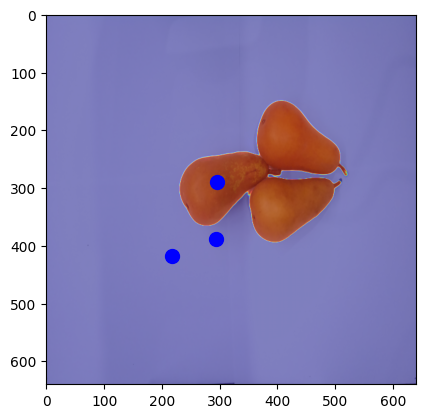

(49.304254964192715, array([17.04999924, 20.75      , 13.85000038]))

In [44]:
table_area = 1627.1
a = Reshala(table_area)

a("4", True)

In [20]:
import numpy as np
from scipy.ndimage import label

def find_precise_blobs(matrix, min_size=2):
    structure = np.array([[1,1,1], [1,1,1], [1,1,1]])  
    labeled, num_features = label(matrix, structure=structure)
    
    blobs = []
    
    for i in range(1, num_features + 1):
        coords = np.argwhere(labeled == i) 
        
        if len(coords) >= min_size:  
            y_min, x_min = coords.min(axis=0)  
            y_max, x_max = coords.max(axis=0) 
            blobs.append((y_min, x_min, y_max + 1, x_max + 1))  
    
    return blobs  


matrix = np.array([
    [0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0, 1, 1],
    [0, 1, 1, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 1, 1, 1],
])


blobs = find_precise_blobs(matrix, min_size=2)
blobs

[(np.int64(1), np.int64(1), np.int64(3), np.int64(3)),
 (np.int64(1), np.int64(5), np.int64(3), np.int64(7)),
 (np.int64(4), np.int64(4), np.int64(6), np.int64(7))]

In [501]:
image = read_image(f'datasets/camera/{4}.jpg')
        
transform = Resize((640,640))
image = transform(image/255.0)
image = torch.unsqueeze(image, 0)

image = image.float()

with torch.no_grad():
    mask = a.segmentator(image.to("cuda:0")).view((640,640)).to('cpu').numpy()

ind = np.where(mask > 0.9)
pic = np.zeros((640,640))
pic[ind] = 1

centers = find_precise_blobs(pic)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12132499..1.0000002].


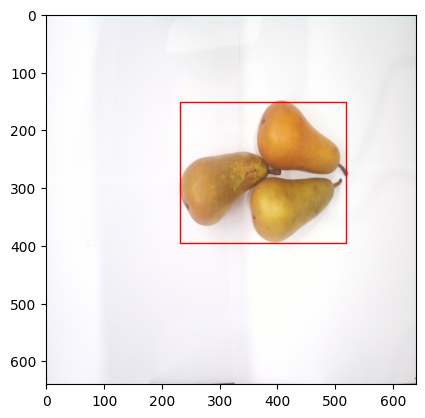

In [502]:
from matplotlib.patches import Rectangle

np_image = torch.squeeze(image, 0).to('cpu').numpy()
np_image = np_image.swapaxes(1,2).swapaxes(0,2)

fig, ax = plt.subplots()

ax.imshow(np_image)
for rect in centers:
    rectanle = Rectangle((rect[1], rect[0]), rect[3]-rect[1], rect[2]-rect[0], linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rectanle)

plt.show()

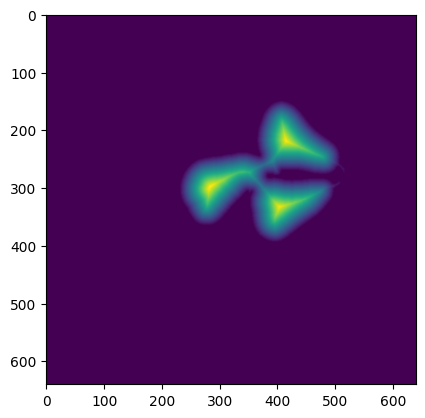

In [503]:
import cv2 as cv

# img = cv.cvtColor(pic, cv2.COLOR_BGR2GRAY)

dist = cv.distanceTransform(pic.astype(np.uint8)*255, cv.DIST_L2,5)
plt.imshow(dist)

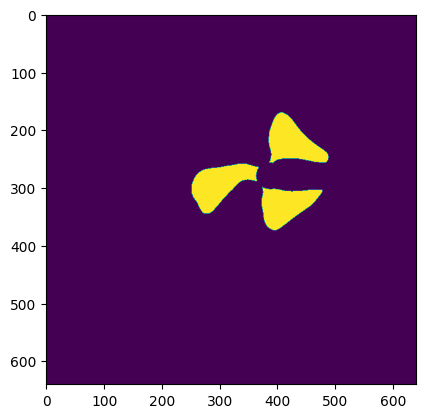

In [504]:
_, distThresh = cv.threshold(dist, 20, 255, cv.THRESH_BINARY)
plt.imshow(distThresh)

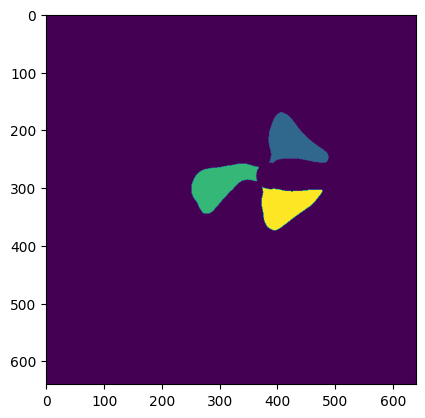

In [505]:
distThresh = np.uint8(distThresh)
_, labels = cv.connectedComponents(distThresh)

plt.imshow(labels)

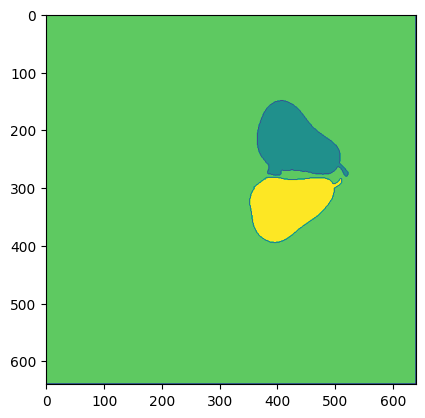

In [510]:
labels = np.int32(labels)
labels_final = cv.watershed((np_image*255).astype(np.uint8), labels)

plt.imshow(labels_final)